TARIFF PRICING AGENT

In [58]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [59]:
df_pred = pd.read_csv("outputs/demand_predictions.csv",parse_dates=["datetime"])

In [60]:
urban_df  = pd.read_csv("outputs/urbanev_clean.csv",parse_dates=["datetime"])

In [ ]:
acn_df  = pd.read_csv("outputs/acn_cleaned_processed.csv",parse_dates=["connectionTime"])

In [62]:
print(f"  Demand predictions : {len(df_pred):,} rows")
print(f"  UrbanEV clean      : {len(urban_df):,}  rows")
print(f"  ACN sessions       : {len(acn_df):,}  rows")

  Demand predictions : 426,816 rows
  UrbanEV clean      : 2,134,080  rows
  ACN sessions       : 13,827  rows


In [63]:
df = df_pred.merge(
    urban_df[["datetime", "district_id", "volume_kwh", "total_chargers","dynamic_pricing", "CBD", "price_cny_per_kwh"]],
    on=["datetime", "district_id"],
    how="left"
)
 
print(f"  Merged shape: {df.shape}")

  Merged shape: (426816, 13)


In [64]:
FLAT_RATE_INR        = 15.0    # rupees/kWh baseline 
SURGE_THRESHOLD      = 0.80    # above this surge pricing (from problem statement)
DISCOUNT_THRESHOLD   = 0.30    # below this discount pricing (from problem statement)

In [65]:
def compute_dynamic_tariff(predicted_util):
    u = predicted_util
    conditions = [
        u > 0.90,  #  Extreme surge 
        u > 0.80,   # high surge 
        u > 0.60, #  Moderate premium  
        u >= 0.30,  #Base rate 
        u >= 0.20,#Mild discount  
        u < 0.20 #Deep discount
    ]
    multipliers = [1.50,1.30,1.15,1.05,1.00,0.95]
    return np.select(conditions, multipliers, default=1.00)


In [66]:
df["tariff_multiplier"]   = compute_dynamic_tariff(df["predicted_utilization"])
df["dynamic_price_inr"]   = FLAT_RATE_INR * df["tariff_multiplier"]

In [67]:
df["pricing_action"] = pd.cut(
    df["tariff_multiplier"],
    bins=[0, 0.75, 0.90, 1.05, 1.15, 1.35, 2.0],
    labels=["Deep discount", "Mild discount", "Base rate","Mild surge", "High surge", "Extreme surge"],
)

In [68]:
print("Pricing action distribution:")
print(df["pricing_action"].value_counts().to_string())
print(f"\n  Avg dynamic tariff : ₹{df['dynamic_price_inr'].mean():.2f}/kWh")
print(f"  Min tariff: ₹{df['dynamic_price_inr'].min():.2f}/kWh")
print(f"  Max tariff: ₹{df['dynamic_price_inr'].max():.2f}/kWh")

Pricing action distribution:
pricing_action
Base rate        399172
Mild surge        24074
High surge         1877
Extreme surge      1693
Deep discount         0
Mild discount         0

  Avg dynamic tariff : ₹15.18/kWh
  Min tariff: ₹14.25/kWh
  Max tariff: ₹22.50/kWh


DEMAND ELASTICITY (how demand responds to price changes)

In [69]:
PRICE_ELASTICITY = -0.4  
df["price_change"] = (df["dynamic_price_inr"] - FLAT_RATE_INR) / FLAT_RATE_INR
df["demand_change"] = PRICE_ELASTICITY * df["price_change"]

In [70]:
df["volume_adjusted_kwh"] = df["volume_kwh"] * (
    1 + df["demand_change"]
).clip(lower=0.20, upper=1.50)

In [71]:
df["volume_adjusted_kwh"] = df["volume_adjusted_kwh"].fillna(0)  

 REVENUE CALCULATION

In [72]:
df["revenue_baseline_cny"]  = df["volume_kwh"] * df["price_cny_per_kwh"]
df["revenue_dynamic_cny"]   = df["volume_adjusted_kwh"] * df["price_cny_per_kwh"] * df["tariff_multiplier"]

In [73]:
revenue_df = df[df["revenue_baseline_cny"] > 0].copy()

In [74]:
total_baseline_revenue = revenue_df["revenue_baseline_cny"].sum()
total_dynamic_revenue  = revenue_df["revenue_dynamic_cny"].sum()

In [75]:
revenue_gain= (total_dynamic_revenue - total_baseline_revenue) / total_baseline_revenue * 100
 
print(f"  Total baseline revenue: {total_baseline_revenue:,.1f} CNY")
print(f"  Total dynamic revenue: {total_dynamic_revenue:,.1f} CNY")
print(f"  Revenue Gain: {revenue_gain:+.2f}%")

  Total baseline revenue: 14,388,544.9 CNY
  Total dynamic revenue: 14,838,594.9 CNY
  Revenue Gain: +3.13%


In [ ]:
ratio = (
    df["volume_adjusted_kwh"]
    / df["volume_kwh"].replace(0, np.nan)
)

df["utilization_after_pricing"] = (
    df["predicted_utilization"] * ratio
)

df["utilization_after_pricing"] = (
    df["utilization_after_pricing"]
    .fillna(df["predicted_utilization"])
)

df["utilization_after_pricing"] = (
    df["utilization_after_pricing"]
    .clip(0, 1)
)

UTILIZATION METRICS

In [84]:
avg_util_before = df["predicted_utilization"].mean()

avg_util_after = df["utilization_after_pricing"].mean()

util_change_pct = (
    (avg_util_after - avg_util_before)
    / avg_util_before
) * 100

 VARIANCE METRICS

In [85]:

var_before = df["predicted_utilization"].var()

var_after = df["utilization_after_pricing"].var()

variance_reduction_pct = (
    (var_before - var_after)
    / var_before
) * 100


In [86]:
print("UTILIZATION ANALYSIS")

print(f"Avg Utilization Before : {avg_util_before:.2%}")
print(f"Avg Utilization After  : {avg_util_after:.2%}")
print(f"Utilization Change     : {util_change_pct:+.2f}%")




UTILIZATION ANALYSIS
Avg Utilization Before : 29.09%
Avg Utilization After  : 28.54%
Utilization Change     : -1.90%


In [87]:
print("VARIANCE ANALYSIS")


print(f"Variance Before        : {var_before:.6f}")
print(f"Variance After         : {var_after:.6f}")
print(f"Variance Reduction     : {variance_reduction_pct:+.2f}%")

VARIANCE ANALYSIS
Variance Before        : 0.030996
Variance After         : 0.026978
Variance Reduction     : +12.96%


 CONGESTION ANALYSIS

In [88]:
before_congestion = (
    df["predicted_utilization"] > 0.80
).mean()

after_congestion = (
    df["utilization_after_pricing"] > 0.80
).mean()

congestion_reduction = (
    (before_congestion - after_congestion)
    / before_congestion
) * 100



In [89]:
print("CONGESTION ANALYSIS")

print(f"Congested Periods Before : {before_congestion:.2%}")
print(f"Congested Periods After  : {after_congestion:.2%}")
print(f"Congestion Reduction     : {congestion_reduction:+.2f}%")

CONGESTION ANALYSIS
Congested Periods Before : 0.84%
Congested Periods After  : 0.00%
Congestion Reduction     : +100.00%


In [93]:
print(acn_df.columns.tolist())

['sessionID', 'stationID', 'siteID', 'clusterID', 'spaceID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'kWhRequested', 'session_duration_hours', 'charging_duration_hours', 'idle_time_hours', 'avg_charging_rate', 'hour', 'day_of_week', 'month', 'is_weekend', 'peak_period', 'baseline_revenue']


In [97]:
df["queue_length_proxy"] = np.select(
    [
        df["predicted_utilization"] > 0.90,
        df["predicted_utilization"] > 0.80,
        df["predicted_utilization"] > 0.60,
        df["predicted_utilization"] > 0.40
    ],
    [5, 4, 3, 2],
    default=1
)

In [102]:
max_queue = df["queue_length_proxy"].max()
df["util_proxy"] = df["queue_length_proxy"] / max(max_queue, 1)
 
df["tariff_multiplier"]  = compute_dynamic_tariff(df["util_proxy"])
df["dynamic_price_inr"]  = FLAT_RATE_INR *df["tariff_multiplier"]
df["revenue_dynamic_inr"]= acn_df["kWhDelivered"] * df["dynamic_price_inr"]
df["revenue_baseline_inr"]=acn_df["kWhDelivered"] * FLAT_RATE_INR
 

In [103]:
acn_baseline = df["revenue_baseline_inr"].sum()
acn_dynamic  = df["revenue_dynamic_inr"].sum()
acn_gain_pct = (acn_dynamic - acn_baseline) / acn_baseline * 100


In [104]:
 
print(f"  ACN baseline revenue  : ₹{acn_baseline:,.0f}")
print(f"  ACN dynamic revenue   : ₹{acn_dynamic:,.0f}")
print(f"  ACN Revenue Gain      : {acn_gain_pct:+.2f}%")

  ACN baseline revenue  : ₹1,695,013
  ACN dynamic revenue   : ₹1,730,923
  ACN Revenue Gain      : +2.12%


SAVE RESULTS AND METRICS

In [106]:
print(acn_df.columns.tolist())

['sessionID', 'stationID', 'siteID', 'clusterID', 'spaceID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'kWhRequested', 'session_duration_hours', 'charging_duration_hours', 'idle_time_hours', 'avg_charging_rate', 'hour', 'day_of_week', 'month', 'is_weekend', 'peak_period', 'baseline_revenue']


In [110]:
df[["datetime", "district_id", "utilization_rate", "predicted_utilization",
    "tariff_multiplier", "dynamic_price_inr", "pricing_action",
    "volume_kwh", "volume_adjusted_kwh",
    "revenue_baseline_cny","revenue_dynamic_cny","dynamic_price_inr","revenue_baseline_inr","util_proxy", "tariff_multiplier",
        "revenue_dynamic_inr"]].to_csv(
    "outputs/tariff_results.csv", index=False
)
 

acn_df[["sessionID", "stationID", "hour", "peak_period",
        "kWhDelivered"
      ]].to_csv(
    "outputs/acn_tariff_results.csv", index=False
)
 

metrics_df = pd.DataFrame({
    "Agent"  : ["Tariff Pricing Agent"] * 4,
    "Metric" : ["Revenue Gain % (UrbanEV/CNY)","Revenue Gain % (ACN/INR)","Off-Peak Volume Uplift %","Utilization Variance Reduction %"],
    "Value"  : [revenue_gain, acn_gain_pct, offpeak_uplift_pct,
                (var_util_before - var_util_after) / var_util_before * 100]
})
metrics_df.to_csv("outputs/tariff_metrics.csv", index=False)
print(" Saved all tariff output files")

 Saved all tariff output files


In [113]:
import matplotlib.pyplot as plt
C_GREEN  = "#2d6a4f"
C_ORANGE = "#e07b39"
C_BLUE   = "#1e6091"
C_RED    = "#c1121f"
C_GREY   = "#6c757d"

   Saved chart 12


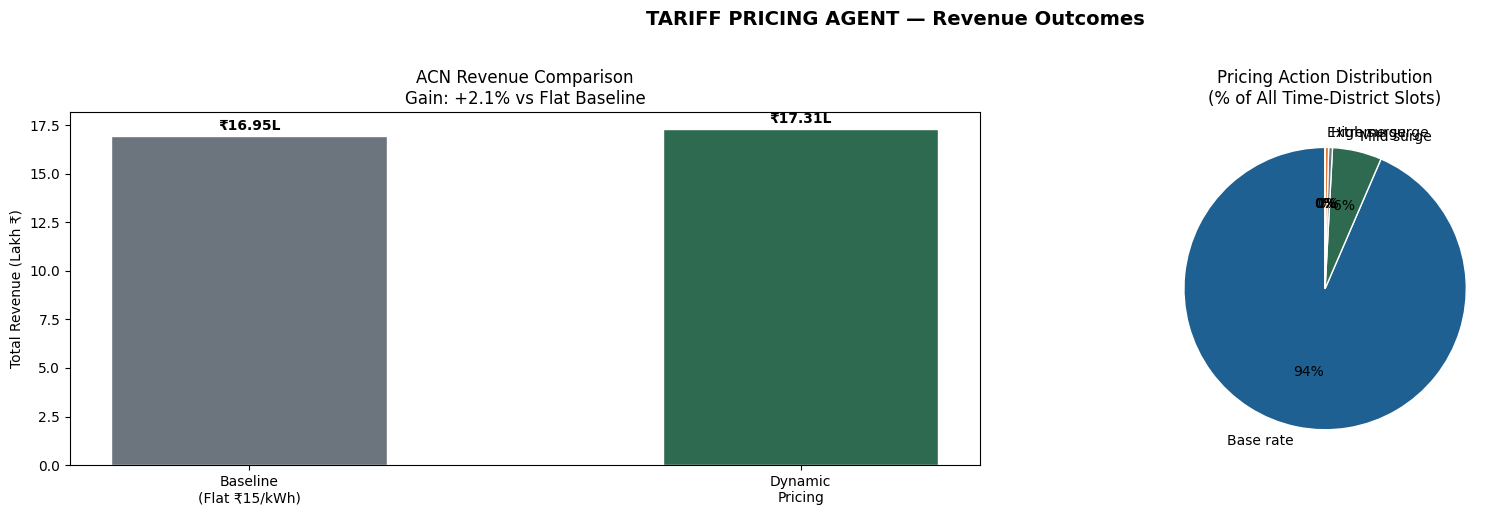

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

ax = axes[0]

categories = ["Baseline\n(Flat ₹15/kWh)", "Dynamic\nPricing"]
values = [acn_baseline / 1e5, acn_dynamic / 1e5]
colors_bar = [C_GREY, C_GREEN]

bars = ax.bar(
    categories,
    values,
    color=colors_bar,
    edgecolor="white",
    width=0.5
)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"₹{val:.2f}L",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylabel("Total Revenue (Lakh ₹)")
ax.set_title(
    f"ACN Revenue Comparison\nGain: {acn_gain_pct:+.1f}% vs Flat Baseline"
)

ax = axes[1]

action_counts = df["pricing_action"].value_counts()

colors_pie = [
    C_BLUE,
    C_GREEN,
    C_GREY,
    C_ORANGE,
    C_RED,
    "#8B0000"
]

action_counts.plot(
    kind="pie",
    ax=ax,
    colors=colors_pie[:len(action_counts)],
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1
    }
)

ax.set_ylabel("")
ax.set_title(
    "Pricing Action Distribution\n(% of All Time-District Slots)"
)

plt.suptitle("TARIFF PRICING AGENT — Revenue Outcomes",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/charts/12_tariff_revenue.png", dpi=150, bbox_inches="tight")

print("   Saved chart 12")



Utilization impact chart saved


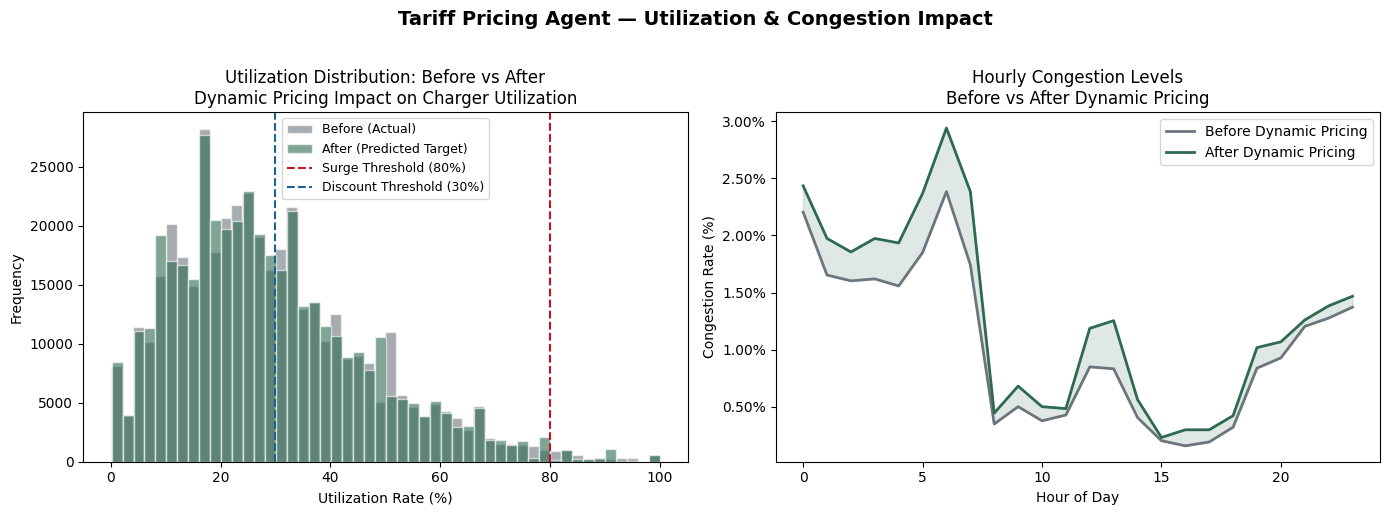

In [122]:
import matplotlib.ticker as mtick
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]

ax.hist(
    df["utilization_rate"] * 100,bins=50,alpha=0.6,color=C_GREY,edgecolor="white",label="Before (Actual)")
ax.hist(
    df["predicted_utilization"] * 100, bins=50,alpha=0.6,color=C_GREEN,edgecolor="white",label="After (Predicted Target)")

ax.axvline(
    80,color=C_RED,linestyle="--",linewidth=1.5,label="Surge Threshold (80%)")


ax.axvline(
    30,color=C_BLUE,linestyle="--",linewidth=1.5,label="Discount Threshold (30%)")


ax.set_xlabel("Utilization Rate (%)")
ax.set_ylabel("Frequency")

ax.set_title(
    "Utilization Distribution: Before vs After\n"
    "Dynamic Pricing Impact on Charger Utilization"
)

ax.legend(fontsize=9)

ax = axes[1]

congestion_before = (
    df.groupby(df["datetime"].dt.hour)["congestion_flag"]
    .mean() * 100
)

congestion_after = (
    df.groupby(df["datetime"].dt.hour)["predicted_congestion_flag"]
    .mean() * 100
)

ax.plot(
    congestion_before.index,
    congestion_before.values,
    color=C_GREY,
    linewidth=2,
    label="Before Dynamic Pricing"
)

ax.plot(
    congestion_after.index,
    congestion_after.values,
    color=C_GREEN,
    linewidth=2,
    label="After Dynamic Pricing"
)

ax.fill_between(
    congestion_before.index,
    congestion_before.values,
    congestion_after.values,
    alpha=0.15,
    color=C_GREEN
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Congestion Rate (%)")

ax.set_title(
    "Hourly Congestion Levels\n"
    "Before vs After Dynamic Pricing"
)

ax.legend()

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)

plt.suptitle(
    "Tariff Pricing Agent — Utilization & Congestion Impact",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "outputs/charts/13_tariff_utilization.png",
    dpi=150,
    bbox_inches="tight"
)

print("Utilization impact chart saved")

Off-peak demand response chart saved


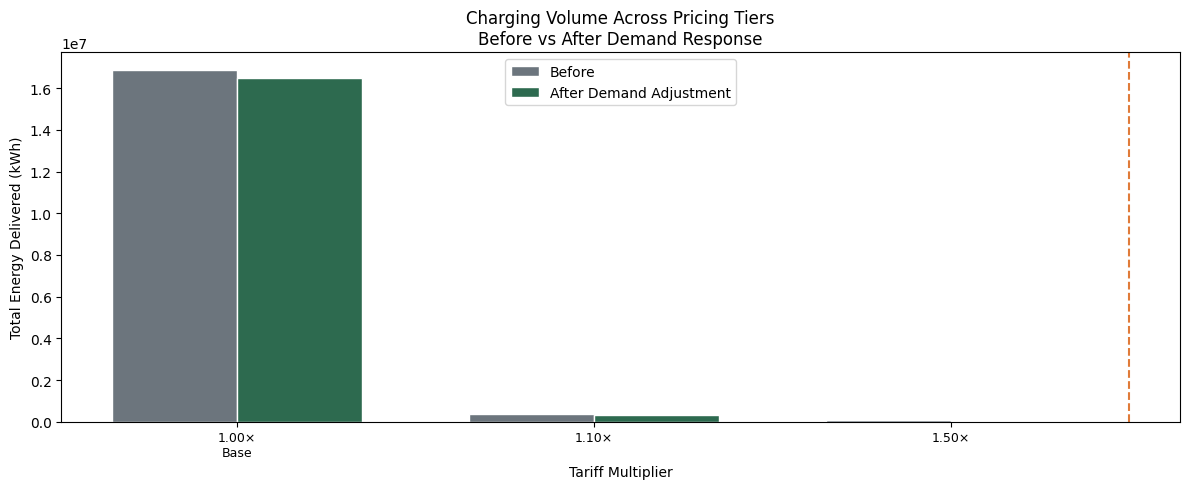

In [123]:
fig, ax = plt.subplots(figsize=(12, 5))

multiplier_bins = [
    0.65,0.75,0.85,0.95,1.05,1.15,1.35,1.55]


multiplier_labels = [
    "0.70×\nDeep Discount","0.80×","0.90×","1.00×\nBase","1.10×","1.30×\nHigh Surge","1.50×"]

df["mult_bucket"] = pd.cut(
    df["tariff_multiplier"],
    bins=multiplier_bins,
    labels=multiplier_labels,
    include_lowest=True
)

vol_by_mult = (
    df.groupby("mult_bucket")
    .agg(
        vol_before=("volume_kwh", "sum"),
        vol_after=("volume_adjusted_kwh", "sum")
    )
)

x = np.arange(len(vol_by_mult))
w = 0.35

ax.bar(
    x - w / 2,
    vol_by_mult["vol_before"],
    w,
    label="Before",
    color=C_GREY,
    edgecolor="white"
)

ax.bar(
    x + w / 2,
    vol_by_mult["vol_after"],
    w,
    label="After Demand Adjustment",
    color=C_GREEN,
    edgecolor="white"
)

ax.set_xticks(x)
ax.set_xticklabels(
    vol_by_mult.index,
    fontsize=9
)

ax.set_xlabel("Tariff Multiplier")
ax.set_ylabel("Total Energy Delivered (kWh)")

ax.set_title(
    "Charging Volume Across Pricing Tiers\n"
    "Before vs After Demand Response"
)

ax.legend()

ax.axvline(
    2.5,
    color=C_ORANGE,
    linestyle="--",
    linewidth=1.5
)

plt.tight_layout()

plt.savefig(
    "outputs/charts/14_offpeak_uplift.png",
    dpi=150,
    bbox_inches="tight"
)

print("Off-peak demand response chart saved")